Imported from: /Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/src/topological_insulator/__init__.py
Building Geometry...
Geometry - Done.
Building 'Island' Hamiltonian...
'Island' Hamiltonian Done.
Calculating 'Island' Eigenvalues...
'Island' Eigenvalues Done
Geometry summary
N sites: 1248
Edge sites: 190
Bulk sites: 1058

Selected sites
bulk vacancy: 623 [36.  0.]
edge vacancy: 0 [1. 0.]
bulk probe   : 624 [37.  0.]
edge probe   : 647 [ 54.         -10.39230485]
NN(v_bulk): [574, 622, 624]
NN(v_edge): [1, 49]


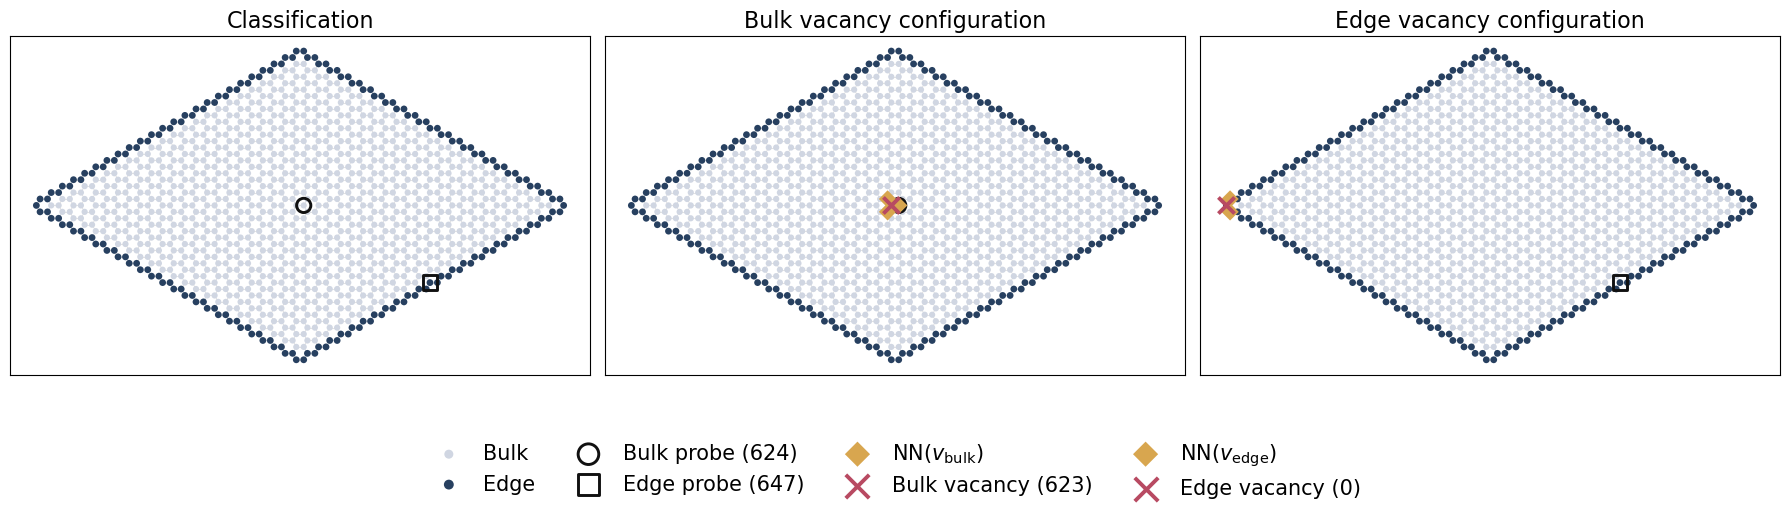

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import topological_insulator
from topological_insulator import Problem

print("Imported from:", topological_insulator.__file__)
importlib.reload(topological_insulator)

# =========================
# Geometry build
# =========================
structure_path = "/Users/vedantdubey/Desktop/UCL/Year 4/PHAS0097 - Physics Project/topological_insulator-main/data/structures"
N_r = 25

problem = Problem(structure_path=structure_path, structure_name="honeycomb.json")
problem.setup(N_r=N_r, N_k=1, location="island", BZ="reduced", dangling_bonds=False)
problem.run(H_type="real")

geom = problem.geometry
sites = np.asarray(geom.sites, dtype=float)
N = len(sites)

C = geom.nn_connectivity_matrix.astype(int)

edge_set = set(getattr(geom, "edge_indices", []))
assert len(edge_set) > 0, "edge_indices is empty."

edge_idx = np.array(sorted(list(edge_set)), dtype=int)
bulk_idx = np.array(sorted(list(set(range(N)) - edge_set)), dtype=int)

print("Geometry summary")
print("N sites:", N)
print("Edge sites:", len(edge_idx))
print("Bulk sites:", len(bulk_idx))

# =========================
# Vacancy + probe selection
# =========================
def neighbours(idx):
    return np.where(C[idx] == 1)[0]

def pick_site_near_point(xy, exclude_edge=False):
    d = np.sum((sites - np.array(xy))**2, axis=1)
    order = np.argsort(d)
    for idx in order:
        if exclude_edge and idx in edge_set:
            continue
        return int(idx)
    return int(order[0])

centre = np.mean(sites, axis=0)

vac_bulk = pick_site_near_point(centre, exclude_edge=True)

d2_edge = np.sum((sites[edge_idx] - centre)**2, axis=1)
vac_edge = int(edge_idx[np.argmax(d2_edge)])

edge_probe_candidates = [i for i in edge_idx if i != vac_edge]
probe_edge = int(edge_probe_candidates[len(edge_probe_candidates)//2])

bulk_candidates = np.array(sorted(list(set(range(N)) - edge_set - {vac_bulk})), dtype=int)
d2_bulk = np.sum((sites[bulk_candidates] - centre)**2, axis=1)
probe_bulk = int(bulk_candidates[np.argmin(d2_bulk)])

nn_bulk_vac = np.array(neighbours(vac_bulk), dtype=int)
nn_edge_vac = np.array(neighbours(vac_edge), dtype=int)

print("\nSelected sites")
print("bulk vacancy:", vac_bulk, sites[vac_bulk])
print("edge vacancy:", vac_edge, sites[vac_edge])
print("bulk probe   :", probe_bulk, sites[probe_bulk])
print("edge probe   :", probe_edge, sites[probe_edge])
print("NN(v_bulk):", nn_bulk_vac.tolist())
print("NN(v_edge):", nn_edge_vac.tolist())

# =========================
# More colourful thesis palette
# =========================
COL_BULK = "#D0D6E2"
COL_EDGE = "#274060"
COL_VAC  = "#B84A62"
COL_NN = "#D8A64F" 
COL_PROBE_BULK = "#111111"
COL_PROBE_EDGE = "#111111"
COL_BOND = "#D8D8D8"
# =========================
# Plot helpers
# =========================
def draw_bonds(ax, sites, C, lw=0.5, color=COL_BOND):
    N = len(sites)
    for i in range(N):
        for j in range(i + 1, N):
            if C[i, j] == 1:
                xi, yi = sites[i]
                xj, yj = sites[j]
                ax.plot([xi, xj], [yi, yj], color=color, linewidth=lw, zorder=1)

def style_ax(ax, title):
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=16)

# =========================
# Three-panel lattice figure
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: classification
ax = axes[0]
draw_bonds(ax, sites, C)
ax.scatter(
    sites[bulk_idx, 0], sites[bulk_idx, 1],
    s=20, color=COL_BULK, edgecolors="none", zorder=2, label="Bulk"
)
ax.scatter(
    sites[edge_idx, 0], sites[edge_idx, 1],
    s=24, color=COL_EDGE, edgecolors="none", zorder=3, label="Edge"
)
ax.scatter(
    sites[[probe_bulk], 0], sites[[probe_bulk], 1],
    s=105, marker="o", facecolors="none", edgecolors=COL_PROBE_BULK,
    linewidths=2.1, zorder=5, label=f"Bulk probe ({probe_bulk})"
)
ax.scatter(
    sites[[probe_edge], 0], sites[[probe_edge], 1],
    s=105, marker="s", facecolors="none", edgecolors=COL_PROBE_EDGE,
    linewidths=2.1, zorder=5, label=f"Edge probe ({probe_edge})"
)
style_ax(ax, "Classification")

# Panel 2: bulk vacancy
ax = axes[1]
draw_bonds(ax, sites, C)
ax.scatter(
    sites[bulk_idx, 0], sites[bulk_idx, 1],
    s=20, color=COL_BULK, edgecolors="none", zorder=2, label="Bulk"
)
ax.scatter(
    sites[edge_idx, 0], sites[edge_idx, 1],
    s=24, color=COL_EDGE, edgecolors="none", zorder=3, label="Edge"
)
ax.scatter(
    sites[nn_bulk_vac, 0], sites[nn_bulk_vac, 1],
    s=78, marker="D", color=COL_NN, edgecolors="none", zorder=6,
    label=rf"NN$(v_{{\mathrm{{bulk}}}})$"
)
ax.scatter(
    sites[[vac_bulk], 0], sites[[vac_bulk], 1],
    s=135, marker="x", color=COL_VAC, linewidths=2.8, zorder=7,
    label=f"Bulk vacancy ({vac_bulk})"
)
ax.scatter(
    sites[[probe_bulk], 0], sites[[probe_bulk], 1],
    s=105, marker="o", facecolors="none", edgecolors=COL_PROBE_BULK,
    linewidths=2.1, zorder=5, label=f"Bulk probe ({probe_bulk})"
)
style_ax(ax, "Bulk vacancy configuration")

# Panel 3: edge vacancy
ax = axes[2]
draw_bonds(ax, sites, C)
ax.scatter(
    sites[bulk_idx, 0], sites[bulk_idx, 1],
    s=20, color=COL_BULK, edgecolors="none", zorder=2, label="Bulk"
)
ax.scatter(
    sites[edge_idx, 0], sites[edge_idx, 1],
    s=24, color=COL_EDGE, edgecolors="none", zorder=3, label="Edge"
)
ax.scatter(
    sites[nn_edge_vac, 0], sites[nn_edge_vac, 1],
    s=78, marker="D", color=COL_NN, edgecolors="none", zorder=6,
    label=rf"NN$(v_{{\mathrm{{edge}}}})$"
)
ax.scatter(
    sites[[vac_edge], 0], sites[[vac_edge], 1],
    s=135, marker="x", color=COL_VAC, linewidths=2.8, zorder=7,
    label=f"Edge vacancy ({vac_edge})"
)
ax.scatter(
    sites[[probe_edge], 0], sites[[probe_edge], 1],
    s=105, marker="s", facecolors="none", edgecolors=COL_PROBE_EDGE,
    linewidths=2.1, zorder=5, label=f"Edge probe ({probe_edge})"
)
style_ax(ax, "Edge vacancy configuration")

# Shared legend
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15,
    markerscale=1.45,
    handlelength=1.9,
    handletextpad=0.7,
    columnspacing=1.6
)

fig.subplots_adjust(bottom=0.16, wspace=0.12)

plt.tight_layout()
plt.savefig("lattice_bulk_edge_vacancy_plot_colourful_thesis.png", dpi=300, bbox_inches="tight")
plt.show()
